In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Assumptions

steady incompressible (turbulent?)



In [3]:
measurement_data = np.loadtxt("data.txt")
t, p1, p2 = measurement_data[:,0], measurement_data[:,1], measurement_data[:,2]

L = 9
D = 0.1
f = 0.02  # friction factor
R_specific = 286.9  # J /(kg*K)  for dry air
p_atmospheric = 99700  # Pa
Temperature = 26 + 273.15  # Kelvin
rho = p_atmospheric / (R_specific * Temperature)
print(rho)

1.1616508188327486


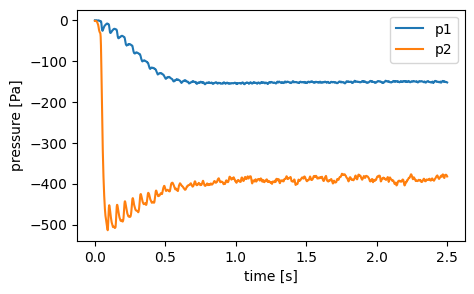

In [4]:
plt.figure(figsize=(5, 3))
plt.plot(t, p1, label="p1")
plt.plot(t, p2, label="p2")
plt.xlabel("time [s]")
plt.ylabel("pressure [Pa]")
plt.legend()

Calculate mean speed

In [5]:
delta_p = p1-p2
L2 = 8.8
p_2 = -400

simple bernoulli:

In [14]:
v_simple = np.sqrt(-2*p1 / (rho))

Advanced bernouli:

In [15]:

v_advanced = np.sqrt( -2 * p1 / ((f*L/D+1)*rho))


"Correct" bernoulli:

In [16]:
v_correct = np.sqrt(2 * delta_p * D / (f * L * rho))

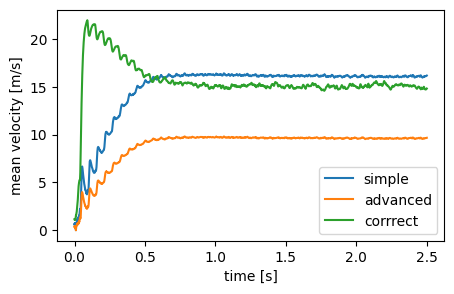

In [17]:
plt.figure(figsize=(5,3))
plt.plot(t, v_simple, label="simple")
plt.plot(t, v_advanced, label="advanced")
plt.plot(t, v_correct, label="corrrect")
plt.xlabel("time [s]")
plt.ylabel("mean velocity [m/s]")
plt.legend()

In [10]:
def dydt(t, y):
    return (-y**2*rho/2 - p_2 - f * L2/D * (rho*y**2)/2)/(rho*L2)

def dydt2(t, y):
    return (-y**2*(f*L/D*rho/2+rho/2) - p_2 - f * L2/D * (rho*y**2)/2)/(rho*L2)

def dydt3(t, y):
    return ((y**2*f*L*rho+2*p_2*D)/2*D - p_2 - f * L2/D * (rho*y**2)/2)/(rho*L2)

In [11]:
y0 = [0]

t_span = (0, 2.5)

solution = solve_ivp(dydt, t_span, y0, t_eval=np.linspace(t_span[0], t_span[1], 100))
solution2 = solve_ivp(dydt2, t_span, y0, t_eval=np.linspace(t_span[0], t_span[1], 100))
solution3 = solve_ivp(dydt3, t_span, y0, t_eval=np.linspace(t_span[0], t_span[1], 100))

In [12]:
mable_sol = ( np.tanh(t * np.sqrt(delta_p*D*L2*f*rho*2) /2*rho*L2*D) * np.sqrt(delta_p * D * L2 * f * rho*2) ) / (L2*f*rho)

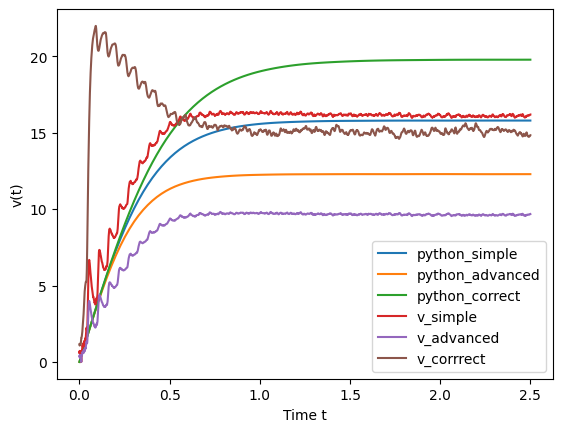

In [13]:
plt.plot(solution.t, solution.y[0], label="python_simple")
plt.plot(solution2.t, solution2.y[0], label="python_advanced")
plt.plot(solution3.t, solution3.y[0], label="python_correct")
#plt.plot(t, mable_sol, label="analytic")
plt.plot(t, v_simple, label="v_simple")
plt.plot(t, v_advanced, label="v_advanced")
plt.plot(t, v_correct, label="v_corrrect")

plt.xlabel('Time t')
plt.ylabel('v(t)')
plt.legend()